# Networks with StarLib rates

StarLib is a library of thermonuclear reaction rates and weak laboratory interaction rates tabulated as a function of temperature. Its key distinction from other sources is that it provides factor uncertainties for each tabulated rate. Here, we elaborate upon its current implementation within pynucastro and provide examples to illustrate its usage.

In [1]:
import pynucastro as pyna

The intended way to access StarLib rates in pynucastro is through a {py:obj}`StarLibLibrary <pynucastro.rates.library.StarLibLibrary>`. When an instance of `StarLibLibrary` is created without an argument, it returns a {py:obj}`Library <pynucastro.rates.library.Library>` holding instances of {py:obj}`StarLibRate <pynucastro.rates.starlib_rate.StarLibRate>` at their respective median values, i.e., no sampling is performed.

In [2]:
sl = pyna.StarLibLibrary()

In [3]:
nuclei =  ["p", "he4", "c12", "c13", "n13",
           "n14", "n15", "o14", "o15" ]

## Integrating Networks with sampled rates

First we'll create a network with the median rates

In [4]:
smrates = sl.linking_nuclei(nuclei)
smnet = pyna.PythonNetwork(libraries=smrates)

and set the thermodynamic conditions (roughly corresponding to the center of the Sun)

In [5]:
rho = 150
T = 1.5e7

comp = pyna.Composition(smnet.unique_nuclei)
comp.X[pyna.Nucleus("p")] = 0.7
comp.X[pyna.Nucleus("he4")] = 0.28
comp.X[pyna.Nucleus("c12")] = 0.02

Y0 = comp.get_molar_array()

### StarLib median rates integration

Now we'll integrate the median network

In [6]:
tmax = 1.e20

In [7]:
sl_sol = smnet.integrate_network(tmax, rho, T, Y0, atol=1.e-8)

### Sampling StarLib uncertainties integrations

Now we'll do a suite of integrations with different random rate samplings.

To enable sampling, we must pass a seed. This seed can be passed when a `StarLibLibrary` is initialized or we can resample an existing `StarLibLibrary`. We can also resample an existing `RateCollection` or any network object.  Here, we demonstrate the latter by creating several variants of our network with different samplings, integrating them, and storing the solution for plotting later.

Note that we seed the numpy random number generator to ensure reproducibility here

In [8]:
data = []

In [9]:
import numpy as np
np.random.seed(1234)

In [11]:
nsamples = 15
for seed in np.random.randint(0, 1000, nsamples):
    smnet.resample(seed=seed)
    sol = smnet.integrate_network(tmax, rho, T, Y0, atol=1.e-8)
    data.append(sol)

### ReacLib comparison integration

We can compare the integration of networks with sampled and median starlib rates against that for ReacLib rates.

In [12]:
rl = pyna.ReacLibLibrary()

In [13]:
rrates = rl.linking_nuclei(nuclei)
rrnet = pyna.PythonNetwork(libraries=rrates)
rl_sol = rrnet.integrate_network(tmax, rho, T, Y0, atol=1.e-8)

## Plotting Solutions

In [14]:
import matplotlib.pyplot as plt

Given that we are comparing network integration across three kinds of rates: sampled StarLib rates, median StarLib rates and ReacLib rates, we can setup color maps to best visualize mass fractions over time.

In [15]:
col_map_light = {'p':'lightsalmon', 'He4':'lightsteelblue',
                 'C12': 'lightgray', 'C13': 'thistle',
                 'N13': 'paleturquoise', 'N14': 'palegreen',
                 'N15': 'pink', 'O14': 'peachpuff', 'O15': 'khaki'}

col_map_med = {'p':'red', 'He4':'royalblue','C12': 'dimgray', 
               'C13': 'mediumorchid', 'N13': 'darkturquoise', 'N14': 'green',
               'N15': 'deeppink', 'O14': 'peru', 'O15': 'gold'}

col_map_dark = {'p':'maroon', 'He4':'navy','C12': 'black', 'C13': 'darkorchid', 
               'N13': 'teal', 'N14': 'darkgreen', 'N15': 'mediumvioletred',
               'O14': 'saddlebrown', 'O15': 'goldenrod'}

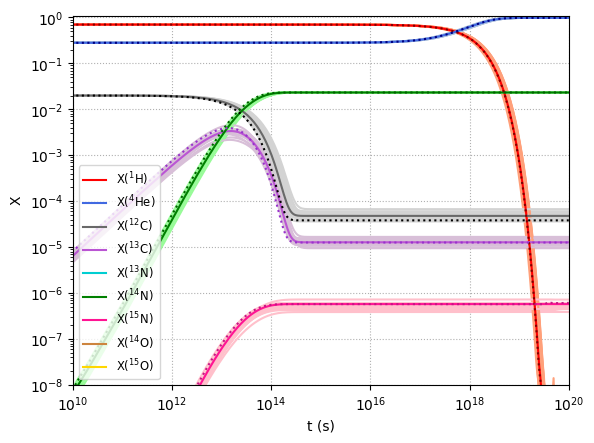

In [16]:
fig, ax = plt.subplots()

# sampled StarLib rates
for sol in data:
    for i, nuc in enumerate(sol.unique_nuclei):
        ax.loglog(sol.t, sol.X[i, :],
                  color=col_map_light[f"{nuc.caps_name}"])

# median StarLib rates
for i, nuc in enumerate(sl_sol.unique_nuclei):
    ax.loglog(sl_sol.t, sl_sol.X[i, :],
              color=col_map_med[f"{nuc.caps_name}"],
              label=f"X(${nuc.pretty}$)")

# Reaclib rates
for i, nuc in enumerate(rl_sol.unique_nuclei):
    ax.loglog(rl_sol.t, rl_sol.X[i, :],
              color=col_map_dark[f"{nuc.caps_name}"], ls=":")

ax.set_xlim(1.e10, 1.e20)
ax.set_ylim(1.e-8, 1.1)
ax.legend(fontsize="small")
ax.set_xlabel("t (s)")
ax.set_ylabel("X")
ax.grid(ls=":")

Here the dotted lines depict the evolution of mass fractions over time given ReacLib rates, the solid lines depict that for median StarLib rates and the faint lines depict that for each sampled StarLib rates.